# Knights

In [100]:
import numpy as np
from matplotlib import pyplot as plt

def spiral_ccw(A):
    A = np.array(A)
    out = []
    while(A.size):
        out.append(A[0][::-1])    # first row reversed
        A = A[1:][::-1].T         # cut off first row and rotate clockwise
    return np.concatenate(out)

In [19]:
def base_spiral(nrow, ncol):
    return spiral_ccw(np.arange(nrow*ncol).reshape(nrow,ncol))[::-1]

In [24]:
def to_spiral(A):
    A = np.array(A)
    B = np.empty_like(A)
    B.flat[base_spiral(*A.shape)] = A.flat
    return B

def from_spiral(A):
    A = np.array(A)
    return A.flat[base_spiral(*A.shape)].reshape(A.shape)

In [122]:
A = np.arange(1,50).reshape(7,7)

In [123]:
A = np.rot90(to_spiral(A).T)
A

array([[37, 36, 35, 34, 33, 32, 31],
       [38, 17, 16, 15, 14, 13, 30],
       [39, 18,  5,  4,  3, 12, 29],
       [40, 19,  6,  1,  2, 11, 28],
       [41, 20,  7,  8,  9, 10, 27],
       [42, 21, 22, 23, 24, 25, 26],
       [43, 44, 45, 46, 47, 48, 49]])

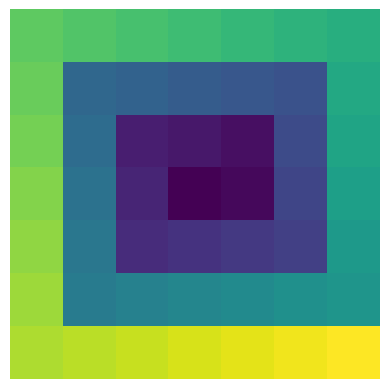

In [124]:
plt.imshow(A, interpolation='nearest');plt.axis('off');plt.show()

In [149]:
inp = [1,2,3,4]
B = np.repeat(inp,[1,8,16,24])
print(B)
parts = [[p+((part.size//4)-1)**2 for p in np.arange(part.size)] for part in np.array_split(B, [1,1+8,1+8+16,1+8+16+24])]
for part in parts:
    np.random.shuffle(part)
    print(part)
B = np.concatenate(parts)
print(B)
B = B.reshape(7,7).astype(int)
B[0,0] = 0
B = np.rot90(to_spiral(B).T)
B

[1 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4]
[np.int64(1)]
[np.int64(2), np.int64(6), np.int64(4), np.int64(8), np.int64(7), np.int64(1), np.int64(3), np.int64(5)]
[np.int64(18), np.int64(16), np.int64(24), np.int64(19), np.int64(15), np.int64(23), np.int64(17), np.int64(10), np.int64(22), np.int64(21), np.int64(13), np.int64(12), np.int64(14), np.int64(9), np.int64(11), np.int64(20)]
[np.int64(28), np.int64(47), np.int64(30), np.int64(36), np.int64(45), np.int64(43), np.int64(31), np.int64(48), np.int64(37), np.int64(29), np.int64(25), np.int64(46), np.int64(27), np.int64(33), np.int64(41), np.int64(38), np.int64(26), np.int64(40), np.int64(44), np.int64(42), np.int64(35), np.int64(32), np.int64(39), np.int64(34)]
[]
[ 1.  2.  6.  4.  8.  7.  1.  3.  5. 18. 16. 24. 19. 15. 23. 17. 10. 22.
 21. 13. 12. 14.  9. 11. 20. 28. 47. 30. 36. 45. 43. 31. 48. 37. 29. 25.
 46. 27. 33. 41. 38. 26. 40. 44. 42. 35. 32. 39. 34.]


array([[46, 25, 29, 37, 48, 31, 43],
       [27, 10, 17, 23, 15, 19, 45],
       [33, 22,  8,  4,  6, 24, 36],
       [41, 21,  7,  0,  2, 16, 30],
       [38, 13,  1,  3,  5, 18, 47],
       [26, 12, 14,  9, 11, 20, 28],
       [40, 44, 42, 35, 32, 39, 34]])

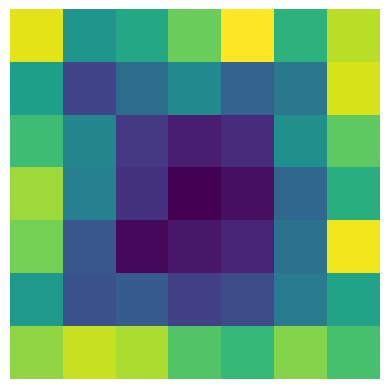

In [150]:
plt.imshow(B);plt.axis('off');plt.show()

In [163]:
size = 5
m = np.matrix([[(abs(i-size//2)**2 + abs(j-size//2)**2) for j in range(0,size)] for i in range(0,size)])
m

matrix([[8, 5, 4, 5, 8],
        [5, 2, 1, 2, 5],
        [4, 1, 0, 1, 4],
        [5, 2, 1, 2, 5],
        [8, 5, 4, 5, 8]])

In [447]:
size = 255
seen = set()
n = 1
indices = {}
indices_count = 0
inc = 0;
A048147 = np.zeros((size, size))
A048147b = np.zeros(A048147.shape)
testm = np.zeros(A048147.shape)
for i in np.arange(0,size):
    for j in np.arange(0,size):
        ij = (i**2 + j**2)
        A048147[i,j] = ij
        if ij in seen:
            indices[ij]=indices[ij]+1
        else:
            indices[ij] = 1
        seen.add(ij)
        inc+=1

count = 0
for i in np.arange(0,size):
    for j in np.arange(0,size):
        ij = (i**2 + j**2)
        A048147b[i,j] = indices[ij]
        
seen = set()
count = {}
for i in np.arange(0,size):
    for j in np.arange(0,size):
        ij = (i**2 + j**2)

        sum = 0
        for k,v in indices.items():
            if k < ij:
                sum+=v
                
        if ij in seen:
            count[ij]+=1
            testm[i,j]=sum+count[ij]
        else:
            testm[i,j]=sum
            count[ij] = 0

        seen.add(ij)
        

#print(countdict)

#print(testm)
#print(A048147)
#print(A048147b)

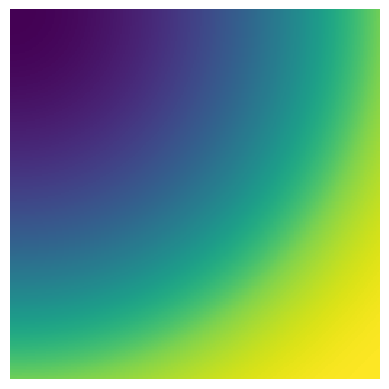

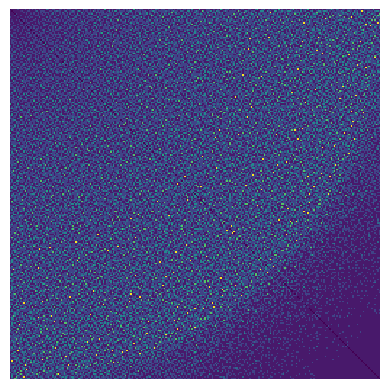

In [448]:
plt.imshow(testm, interpolation='nearest');plt.axis('off');plt.show()
plt.imshow(A048147b, interpolation='nearest');plt.axis('off');plt.show()

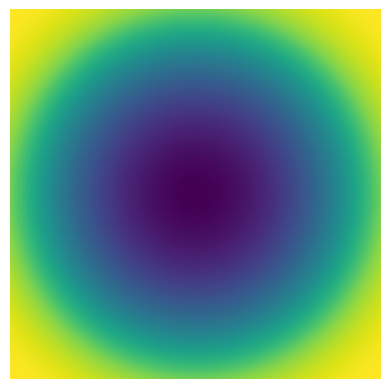

In [449]:
testm1 = (np.copy(testm)+1)
q1 = np.rot90(testm1)
q2 = np.copy(np.rot90(q1))
q1 = q1*4-3
q2 = q2*4-2
#q1 = np.delete(q1, 0, axis=1)
qt = np.hstack((q2,q1))
q3 = np.rot90(np.rot90(np.rot90(testm1)))
#q3 = np.delete(q3, -1, axis=1)
q4 = np.copy(testm1)
q3 = q3*4-1
q4 = q4*4
qb = np.hstack((q3,q4))
qb = np.delete(qb, -1, axis=0)
q = np.vstack((qt,qb))
#print(q1)
#print(q2)
#print(q3)
#print(q4)
#print("---")
q = np.vstack((qt,qb))
q = np.fliplr(q)
q = np.flipud(q)
#print(q)
plt.imshow(q, interpolation='nearest');plt.axis('off');plt.show()